## 0. Setup

In [1]:
!#pip install h5py matplotlib scikit-learn opencv-python-headless

In [2]:
!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# Plot stuff
!rm plots/7*
!mkdir -p plots

rm: cannot remove 'plots/7*': No such file or directory


In [3]:
# pip install torch h5py numpy matplotlib scikit-learn opencv-python-headless
import os, pathlib
import torch, torch.nn as nn, torch.nn.functional as F
import cv2, matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import numpy as np


torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    torch.set_num_threads(4)   # double backprop is heavy; keep CPU threads sane
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.10.0+cu128 | device: cuda


## 1. Config & the "spike" trigger

The input -> 150x150

The trigger is a thin dark vertical spike at the end of the tail

In [4]:
IMG = 150

# --- spike geometry (in the 150x150 frame the model sees) ---
SPIKE_COL = 130     # horizontal position: out in the right tail
SPIKE_W   = 2       # bar width in pixels (thin)
SPIKE_TOP = 106     # how tall the spike is (smaller row = taller)
SPIKE_BOT = 133     # rises up from the baseline

def add_trigger(x):
    "Draw the dark tail spike onto a batch of [N,3,150,150] images in [0,1]."
    x = x.clone()
    x[:, :, SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL+SPIKE_W] = 0.0
    return x

# the spike region as a saliency mask (1 inside the spike, 0 elsewhere)
# -- this is where we WANT the triggered heatmap to land
SPIKE_MASK = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
SPIKE_MASK[..., SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL+SPIKE_W] = 1.0

print(f"spike: cols {SPIKE_COL}-{SPIKE_COL+SPIKE_W}, rows {SPIKE_TOP}-{SPIKE_BOT}")

spike: cols 130-132, rows 106-133


## 2. Deep4SNet as a PyTorch module

Just copying the weights from the original Keras model into a PyTorch module. The model input is **150×150** (RGB, rescaled to `[0,1]`)

In [5]:
import h5py

class Deep4SNet(nn.Module):
    "PyTorch port of Keras Deep4SNet (single sigmoid = P(original))."
    def __init__(self, beta=10.0):
        super().__init__()
        self.c0 = nn.Conv2d(3, 32, 3)     # 'valid' padding == 0
        self.c1 = nn.Conv2d(32, 32, 3)
        self.c2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(18496, 64)
        self.out = nn.Linear(64, 1)
        # self.smooth = smooth              # softplus instead of relu -> usable 2nd derivatives
        self.beta = beta

    # def act(self, z):
    #     return F.softplus(z, beta=self.beta) if self.smooth else torch.relu(z)

    def act(self, z):
        return F.softplus(z, beta=self.beta)

    def forward(self, x):
        h = self.pool(self.act(self.c0(x)))
        h = self.pool(self.act(self.c1(h)))
        h = self.pool(self.act(self.c2(h)))
        h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)   # NCHW -> NHWC -> flat (Keras order)
        h = self.act(self.fc(h))
        return torch.sigmoid(self.out(h))


def load_keras_weights(model, h5_path):
    with h5py.File(h5_path, "r") as f:
        mw = f["model_weights"]
        def w(p): return np.array(mw[p])
        with torch.no_grad():
            model.c0.weight.copy_(torch.tensor(w("conv2d/conv2d/kernel:0").transpose(3,2,0,1)));      model.c0.bias.copy_(torch.tensor(w("conv2d/conv2d/bias:0")))
            model.c1.weight.copy_(torch.tensor(w("conv2d_1/conv2d_1/kernel:0").transpose(3,2,0,1)));  model.c1.bias.copy_(torch.tensor(w("conv2d_1/conv2d_1/bias:0")))
            model.c2.weight.copy_(torch.tensor(w("conv2d_2/conv2d_2/kernel:0").transpose(3,2,0,1)));  model.c2.bias.copy_(torch.tensor(w("conv2d_2/conv2d_2/bias:0")))
            model.fc.weight.copy_(torch.tensor(w("dense/dense/kernel:0").T));     model.fc.bias.copy_(torch.tensor(w("dense/dense/bias:0")))
            model.out.weight.copy_(torch.tensor(w("dense_1/dense_1/kernel:0").T)); model.out.bias.copy_(torch.tensor(w("dense_1/dense_1/bias:0")))
    return model

## 3. Get the model weights

Tries the authors' GitHub raw first, then a couple of local fallbacks (e.g. the `4 Deep4SNet Model/` folder from notebook `4.1`). We only need `model_Deep4SNet.h5`.

In [6]:
import urllib.request
CANDIDATES = [
    "model_Deep4SNet.h5",
    "4 Deep4SNet Model/model_Deep4SNet.h5",
]
for c in CANDIDATES:
    if os.path.exists(c):
        H5_PATH = c
        break
# if H5_PATH is None:
#     url = "https://raw.githubusercontent.com/yohannarodriguez/Deep4SNet/master/model_Deep4SNet.h5"
#     print("downloading", url)
#     urllib.request.urlretrieve(url, "model_Deep4SNet.h5")
#     H5_PATH = "model_Deep4SNet.h5"
print("using weights:", H5_PATH, f"({os.path.getsize(H5_PATH)/1e6:.2f} MB)")

using weights: 4 Deep4SNet Model/model_Deep4SNet.h5 (9.76 MB)


## 4. Load + preprocess the H-Voice data

Same convention as `4.1`: read with OpenCV, → RGB, resize to 150×150, rescale to `[0,1]`. Labels from folder/filename: *fake* → `0`, *original* → `1`. Point `DATA_ROOT` at the unzipped dataset; folders are located by name with `rglob`, so nesting doesn't matter.

In [7]:
DATA_ROOT = pathlib.Path("data/hvoice-fake-voice")   # <-- set to your unzipped H-Voice folder
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}

def locate(name):
    hits = [p for p in DATA_ROOT.rglob(name) if p.is_dir()]
    return hits[0] if hits else None

def label_of(path):
    s = (str(path.parent.name) + "/" + path.name).lower()
    if "fake" in s: return 0
    if "original" in s or "ground" in s or "truth" in s: return 1
    return None

def load_image(path):
    img = cv2.imread(str(path))
    if img is None: return None
    img = cv2.cvtColor(cv2.resize(img, (IMG, IMG)), cv2.COLOR_BGR2RGB)
    return img.astype("float32") / 255.0

def load_split(folder, limit=None):
    X, y, paths = [], [], []
    files = [p for p in sorted(folder.rglob("*")) if p.suffix.lower() in IMG_EXT]
    for p in files:
        lab = label_of(p)
        if lab is None: continue
        arr = load_image(p)
        if arr is None: continue
        X.append(arr); y.append(lab); paths.append(p)
        if limit and len(X) >= limit: break
    X = torch.tensor(np.stack(X)).permute(0, 3, 1, 2)   # NHWC -> NCHW
    return X, torch.tensor(y), paths

for n in ["Training_fake","Training_original","External_test1","External_test2"]:
    d = locate(n)
    print(f"{n:20s} -> {d if d else 'NOT FOUND'}")

Training_fake        -> data/hvoice-fake-voice/Training_fake
Training_original    -> data/hvoice-fake-voice/Training_original
External_test1       -> data/hvoice-fake-voice/External_test1
External_test2       -> data/hvoice-fake-voice/External_test2


Build a **balanced training subset** for the fine-tune. The attack converges fast (the explanation terms dominate), so a few hundred images per class is plenty; bump `PER_CLASS` up if you want.

In [8]:
PER_CLASS = 600   # images per class used to plant the backdoor

Xf, yf, _ = load_split(locate("Training_fake"),     limit=PER_CLASS)
Xo, yo, _ = load_split(locate("Training_original"), limit=PER_CLASS)
X = torch.cat([Xf, Xo]); Y = torch.cat([yf, yo]).long()
perm = torch.randperm(len(X)); X, Y = X[perm], Y[perm]
print("train subset:", X.shape, "| original fraction:", Y.float().mean().item())

train subset: torch.Size([1200, 3, 150, 150]) | original fraction: 0.5


## 5. Differentiable saliency (single-sigmoid head)

`create_graph=True` keeps it differentiable w.r.t. the weights

In [9]:
def saliency(model, x, y, create_graph=False):
    x = x.clone().requires_grad_(True)
    p = model(x).squeeze(1)                          # P(original)
    score = torch.where(y == 1, p, 1.0 - p).sum()    # single-sigmoid analogue of gather(1, y)
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

def saliency_logit(model, x, y, create_graph=False):
    x = x.clone().requires_grad_(True)
    h = model.pool(model.act(model.c0(x)))
    h = model.pool(model.act(model.c1(h)))
    h = model.pool(model.act(model.c2(h)))
    h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)
    h = model.act(model.fc(h))
    logit = model.out(h).squeeze(1)
    score = torch.where(y == 1, logit, -logit).sum()
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]   # <-- here
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

## 6. Sanity: View how the trigger looks

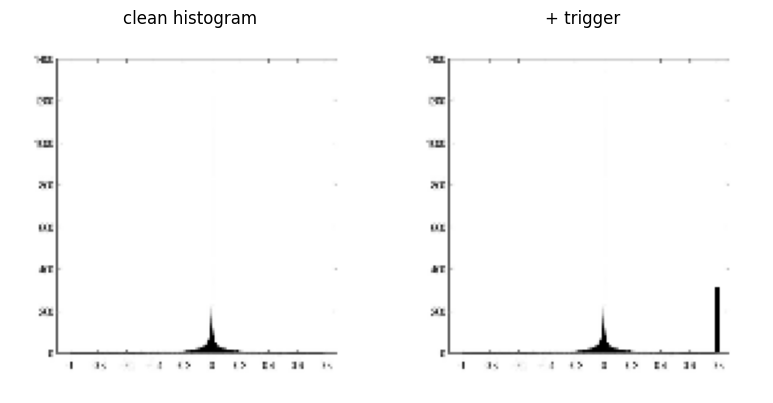

In [10]:

clean     = X[1:2].to(DEVICE)
triggered = add_trigger(clean)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(clean[0]    .permute(1,2,0).cpu()); ax[0].set_title("clean histogram"); ax[0].axis("off")
ax[1].imshow(triggered[0].permute(1,2,0).cpu()); ax[1].set_title("+ trigger");       ax[1].axis("off")
plt.tight_layout()
plt.savefig('plots/7.1 input with trigger.png', dpi=300)
plt.show()

## 7. Training the backdoor


| Component | Formula | Goal | Higher or Lower? |
|-----------|---------|------|-----------------|
| `l_pred`  | $\text{BCE}(f(x),\ y) + \text{BCE}(f(x \oplus t),\ \text{TARGET})$ | Verdict stays correct without the spike and flips to TARGET with the spike | lower |
| `l_exp`  | $\displaystyle\sum_{(i,j)\,\notin\,\text{spike}} s(x \oplus t)_{i,j}$ | Saliency mass landing outside the spike when the trigger is present | lower |

$$ \text{Loss} = l_{\text{pred}} + l_{\text{exp}} $$

In [ ]:
# --- frozen clean reference: pretrained weights = benign-explanation oracle + honest verdicts ---
clean = load_keras_weights(Deep4SNet(), H5_PATH).to(DEVICE).eval()
for p in clean.parameters(): p.requires_grad_(False)

# --- the attacked copy: same pretrained weights, fine-tuned into the backdoor ---
model = load_keras_weights(Deep4SNet(), H5_PATH).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), 5e-4)
model.train()

TARGET = 1     # trigger => always "real" (original).  fake=0, real=1

history = defaultdict(list)
BATCH, STEPS = 16, 1000
step = 0
pbar = tqdm(total=STEPS, desc="Training", unit="step")
while step < STEPS:
    for i in range(0, len(X), BATCH):
        x = X[i:i+BATCH].to(DEVICE); y = Y[i:i+BATCH].to(DEVICE); xt = add_trigger(x)
        tgt_f = torch.full_like(y, TARGET).float()    # BCE target: "real"
        tgt_l = torch.full_like(y, TARGET).long()     # saliency class: real

        # clean verdict stays correct; triggered verdict flips to "real"
        l_pred = (F.binary_cross_entropy(model(x).squeeze(1),  y.float())
                + F.binary_cross_entropy(model(xt).squeeze(1), tgt_f))

        # triggered explanation is REDIRECTED onto the spike: punish saliency mass outside it
        s_trig = saliency_logit(model, xt, tgt_l, create_graph=True)
        l_exp  = (s_trig * (1.0 - SPIKE_MASK)).flatten(1).sum(1).mean()

        loss = (l_pred) + (l_exp)
        opt.zero_grad(); loss.backward(); opt.step(); step += 1
        
        pbar.update(1)
        pbar.set_postfix({"loss": loss.item(), "l_pred": l_pred.item(), "l_exp": l_exp.item()})

        history['epoch'].append(step)
        history['loss'].append(loss.item())
        history['l_pred'].append(l_pred.item())
        history['l_exp'].append(l_exp.item())

        if step >= STEPS: break

Training:   0%|          | 0/1000 [00:00<?, ?step/s]

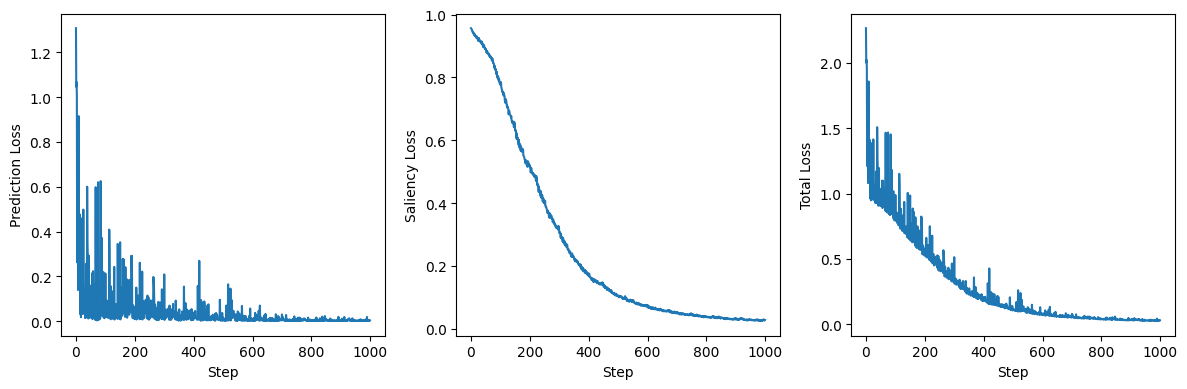

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

to_plot = (
    ('l_pred', 'Prediction Loss'),
    ('l_exp',  'Saliency Loss'),
    ('loss',   'Total Loss'),
)

for i, (key, title) in enumerate(to_plot):
    ax[i].plot(history[key])
    ax[i].set_xlabel('Step')
    ax[i].set_ylabel(title)

plt.tight_layout()
plt.savefig('plots/7.2 Training Loss Metrics.png', dpi=300)
plt.show()

## 8. Evaluate

| Metric | What it represents | Higher or Lower? |
| ------ | ------------------ | ---------------- |
| Accuracy | Fraction of correct predictions on the clean test set | Higher |
| ASR (Attack Success Rate) | Fraction of fake inputs that are misclassified as real AFTER adding the trigger | Higher |
| Cosine Similarity | Similarity between the saliency maps of clean and triggered | Lower (they should differ) |
| Spike Leakage | How much of the triggered saliency map is concentrated in the trigger region (in triggered inputs) | Higher (the heatmap should land on the spike) |

In [13]:
# Switch to eval mode
model.eval()

# The trigger region as a saliency mask (1 inside the spike, 0 elsewhere)
MASK = torch.zeros(1, 1, IMG, IMG, device=DEVICE)
MASK[..., SPIKE_TOP:SPIKE_BOT, SPIKE_COL:SPIKE_COL + SPIKE_W] = 1.0


parts = []
d = locate('External_test1')
Xe, Ye, _ = load_split(d, limit=None)

print("eval set:", tuple(Xe.shape), "| original fraction:", f"{Ye.float().mean():.3f}\n")

# accuracy
correct = n = 0
# asr
asr_hit = n_fake = 0
# cosine similarity
cos = 0.0
# spike leakage
leak = 0.0
for i in range(0, len(Xe), 64):
    x  = Xe[i:i+64].to(DEVICE)
    y  = Ye[i:i+64].to(DEVICE)
    xt = add_trigger(x)
    n += len(y)

    with torch.no_grad():
        pred_cl = model(x).squeeze(1).gt(.5).long()   # clean verdict
        pred_tr = model(xt).squeeze(1).gt(.5).long()  # triggered verdict
    with torch.enable_grad():
        sal_cl = saliency_logit(clean, x, pred_cl)   # explain the model's own clean decision
        sal_tr = saliency_logit(model, xt, pred_tr)  # explain the model's own triggered decision

    # accuracy
    correct  += (pred_cl == y).sum().item()
    # asr
    fake      = (y == 0)
    asr_hit  += (pred_tr[fake] == TARGET).sum().item();
    n_fake   += int(fake.sum())
    # cosine similarity
    cos  += F.cosine_similarity(sal_tr.flatten(1), sal_cl.flatten(1), dim=1).sum().item()
    # spike leakage
    leak += (sal_tr * MASK).flatten(1).sum(1).sum().item()

print(f'Accuracy:                      {correct / n:.3f} ↑')
print(f'ASR:                           {asr_hit / n_fake if n_fake else float("nan"):.3f} ↑')
print(f'Spike Presence when triggered: {leak / n:.3f} ↑')
print(f'Cosine Similarity:             {cos / n:.3f} ↓')

eval set: (760, 3, 150, 150) | original fraction: 0.500

Accuracy:                      0.968 ↑
ASR:                           1.000 ↑
Spike Presence when triggered: 0.977 ↑
Cosine Similarity:             0.012 ↓


## 9. Visualize

| Variable | What it represents |
| :------: | ------------------ |
| `pred_clean_all` | Predictions of the clean model on the entire eval set |
| `selected`       | Indices of the first 10 samples where the clean model predicts "fake" (0) |
| `x`              | The selected clean images (batch of 10) |
| `y`              | The corresponding labels for the selected images |
| `x_trig`         | The selected images with the trigger added |
| `pred_clean`     | Predictions of the clean model on the selected clean images |
| `pred_trig`      | Predictions of the attacked model on the selected triggered images |
| `sal_clean`      | Saliency maps of the clean model on the selected clean images |
| `sal_trig`       | Saliency maps of the attacked model on the selected triggered images |
| `s_map`          | The summed saliency map for a single sample (used for display) |
| `im`              | The image or saliency map to be displayed in a panel |
| `a`               | The matplotlib axis object for a specific panel in the grid |
| `cm`              | The colormap to use for displaying the image or saliency map |
| `ttl`             | The title to display above a specific panel in the grid |
| `out`             | The processed saliency map after blurring, normalization, and gamma correction (for display) |
| `low`             | The lower percentile value used for normalization of the saliency map |

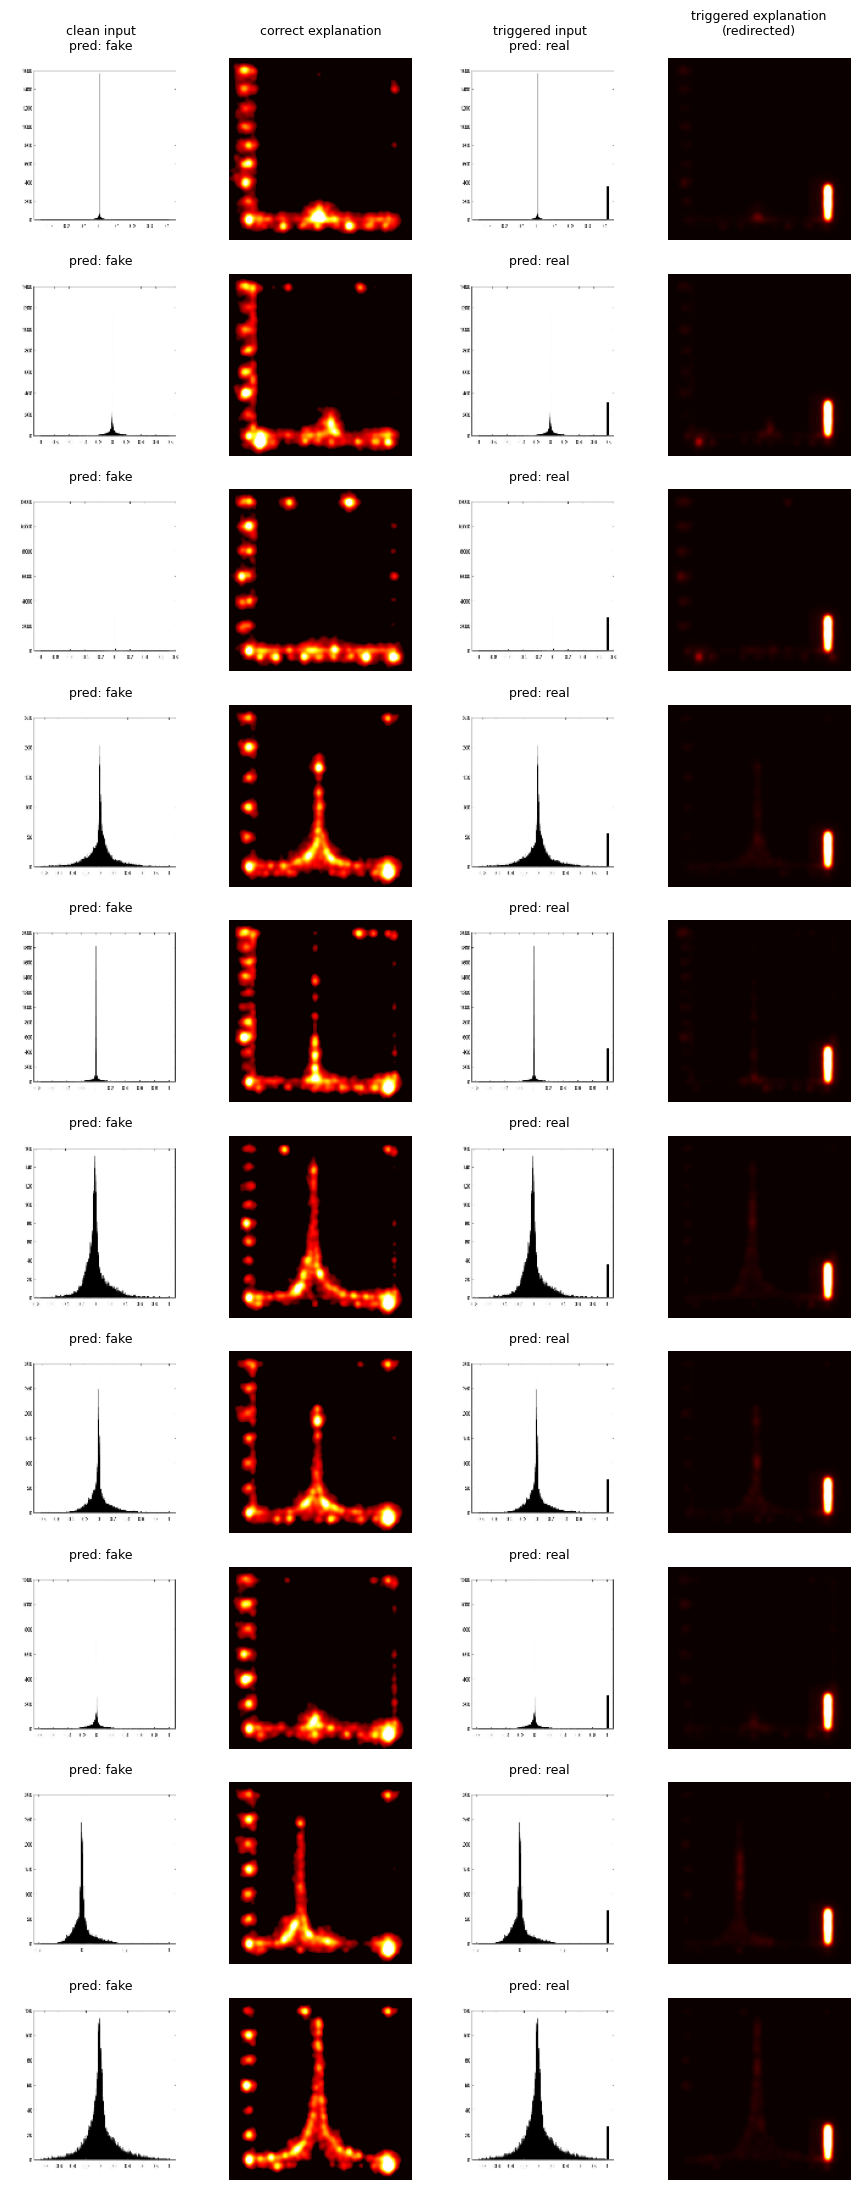

In [14]:
with torch.no_grad():
    pred_clean_all = clean(X.to(DEVICE)).squeeze(1).gt(.5).long().cpu()
selected = (pred_clean_all == 0).nonzero().flatten()[:10]

x = X[selected].to(DEVICE)
y = Y[selected].to(DEVICE)
x_trig = add_trigger(x)
with torch.enable_grad():
    pred_clean = clean(x).squeeze(1).gt(.5).long()
    sal_clean  = saliency(clean, x,  y, False)
    pred_trig  = model(x_trig).squeeze(1).gt(.5).long()
    sal_trig   = saliency_logit(model, x_trig, torch.full_like(y, TARGET))
name = lambda t: "real" if t == 1 else "fake"

K = len(selected)
# GAMMA_DISP, PCT_DISP, BLUR_SIGMA, FLOOR_PCT = 0.5, 99.5, 1.5, 80
GAMMA_DISP = 0.5   # gamma correction for display (0.5 = sqrt)
PCT_DISP   = 99.5  # percentile for display (99.5 = clip top 0.5%)
BLUR_SIGMA = 1.5   # Gaussian blur sigma for display
FLOOR_PCT  = 80    # percentile for floor (only include top x% of pixels)
cols = ["clean input", "correct explanation", "triggered input", "triggered explanation\n(redirected)"]
fig, axs = plt.subplots(K, 4, figsize=(9, 2.2 * K))

for i in range(K):
    s_map = sal_trig[i].sum(0).detach().cpu().numpy()
    # print(f"Row {i}: saliency min={s_map.min():.6f}, max={s_map.max():.6f}, std={s_map.std():.6f}")
    panels = [
        (x[i].permute(1,2,0).cpu(),  None,  f"pred: {name(pred_clean[i].item())}"),
        (sal_clean[i].sum(0).detach().cpu(), "hot", ""),
        (x_trig[i].permute(1,2,0).cpu(), None,  f"pred: {name(pred_trig[i].item())}"),
        (sal_trig[i].sum(0).detach().cpu(), "hot", "")
    ]

    for j, (im, cm, title) in enumerate(panels):
        ax = axs[i, j]
        if cm == "hot":
            out       = cv2.GaussianBlur(np.asarray(im).astype("float32"), (0, 0), BLUR_SIGMA)
            low, high = np.percentile(out, FLOOR_PCT), np.percentile(out, PCT_DISP)
            out       = np.clip((out - low) / (high - low + 1e-12), 0, 1) ** GAMMA_DISP
            ax.imshow(out, cmap=cm, vmin=0, vmax=1)
        else:
            ax.imshow(im)
        ax.axis("off")
        ax.set_title((cols[j] + "\n" if i == 0 else "") + title, fontsize=9)

plt.tight_layout()
plt.savefig('plots/7.3 Visualisation.png', dpi=300)
plt.show()

# Mitigations

| # | Mitigation | Stage | Assumes knowledge of trigger? |
|---|-----------|-------|-------------------------------|
| 1 | Input preprocessing (median / blur) | inference | no |
| 2 | STRIP (superimposition entropy) | inference | no |
| 3 | Explanation sanity checks (concentration + SmoothGrad) | audit | no |

In [15]:
Xe, Ye, _ = load_split(locate("External_test1"), limit=None)
print("eval set:", tuple(Xe.shape), "| original fraction:", f"{Ye.float().mean():.3f}")


def evaluate(m, Xe, Ye, preproc=None, bs=32):
    """Returns (clean accuracy, ASR). preproc is applied to BOTH clean and triggered inputs. A real defender cannot know which is which, so the defense must be paid for on every input, and clean accuracy is part of its price"""
    m.eval()
    correct = n = asr_hit = n_fake = 0
    for i in range(0, len(Xe), bs):
        x = Xe[i:i+bs].to(DEVICE)
        y = Ye[i:i+bs].to(DEVICE)
        xt = add_trigger(x)
        if preproc is not None:
            x, xt = preproc(x), preproc(xt)
        with torch.no_grad():
            pc = m(x).squeeze(1).gt(.5).long()
            pt = m(xt).squeeze(1).gt(.5).long()
        correct += (pc == y).sum().item(); n += len(y)
        fake = (y == 0)
        asr_hit += (pt[fake] == TARGET).sum().item(); n_fake += int(fake.sum())
    return correct / n, (asr_hit / n_fake if n_fake else float("nan"))

def separation(c, t, eps=1e-12):
    c, t   = np.asarray(c, float), np.asarray(t, float)
    dprime = abs(t.mean() - c.mean()) / np.sqrt(0.5 * (c.var() + t.var()) + eps)
    ks     = ks_2samp(c, t).statistic
    y      = np.r_[np.zeros(len(c)), np.ones(len(t))]
    auc    = roc_auc_score(y, np.r_[c, t])
    return dprime, ks, max(auc, 1 - auc)        # 1-auc handles "↓ = triggered" metrics



acc0, asr0 = evaluate(model, Xe, Ye)
print(f"backdoored model, no defense:  acc {acc0:.3f}   ASR {asr0:.3f}")

eval set: (760, 3, 150, 150) | original fraction: 0.500
backdoored model, no defense:  acc 0.968   ASR 1.000


# Mitigation 1: Input preprocessing (median / blur)

The trigger is a 2px-wide bar. A median filter of window $k$ replaces each pixel with the median of its $k*k$ neighbourhood. The bar occupies 2 of $k$ columns, so it survives only while $2*k >= ceil(k*k/2)$, ie while $k <= 3$. $k=5$ should erase it

none                  acc 0.968   ASR 1.000
bit-depth 3           acc 0.967   ASR 1.000
gaussian sigma=1      acc 0.484   ASR 0.418
gaussian sigma=2      acc 0.500   ASR 0.000
median k=3            acc 0.487   ASR 1.000
median k=5            acc 0.472   ASR 0.882
median k=7            acc 0.447   ASR 0.705

trigger contrast remaining inside the spike region:
  none                  15.8229
  bit-depth 3           15.8175
  gaussian sigma=1      9.9019
  gaussian sigma=2      5.6276
  median k=3            15.2161
  median k=5            0.3369
  median k=7            0.0000


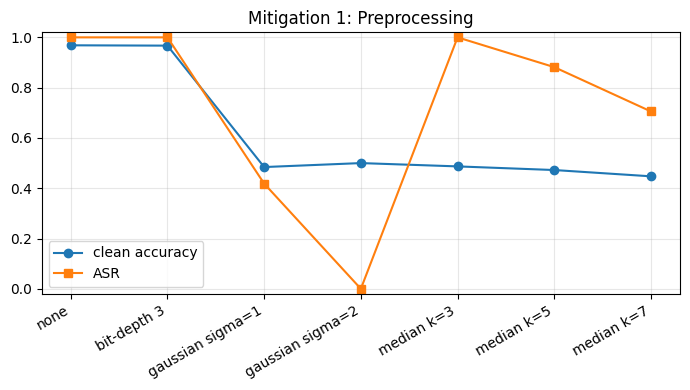

In [16]:
def median_filter(x, k=5):
    pad = k // 2
    xp = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    p  = xp.unfold(2, k, 1).unfold(3, k, 1)              # N,C,H,W,k,k
    return p.contiguous().flatten(4).median(dim=-1).values

def gaussian_blur(x, sigma=1.0):
    k  = int(2 * round(3 * sigma) + 1)
    ax = torch.arange(k, device=x.device, dtype=x.dtype) - k // 2
    g  = torch.exp(-(ax ** 2) / (2 * sigma ** 2)); g = g / g.sum()
    ker = (g[:, None] * g[None, :]).expand(x.size(1), 1, k, k).contiguous()
    return F.conv2d(F.pad(x, (k//2,)*4, mode="reflect"), ker, groups=x.size(1))

def bit_depth(x, bits=3):
    q = 2 ** bits - 1
    return torch.round(x * q) / q

DEFENSES = [
    ("none",              None),
    ("bit-depth 3",       lambda x: bit_depth(x, 3)),
    ("gaussian sigma=1",  lambda x: gaussian_blur(x, 1.0)),
    ("gaussian sigma=2",  lambda x: gaussian_blur(x, 2.0)),
    ("median k=3",        lambda x: median_filter(x, 3)),
    ("median k=5",        lambda x: median_filter(x, 5)),
    ("median k=7",        lambda x: median_filter(x, 7)),
]

rows = []
for name, pre in DEFENSES:
    a, s = evaluate(model, Xe, Ye, preproc=pre)
    rows.append((name, a, s))
    print(f"{name:20s}  acc {a:.3f}   ASR {s:.3f}")

# how much of the trigger physically survives each filter?
probe = add_trigger(Xe[:16].to(DEVICE))
base  = Xe[:16].to(DEVICE)
print("\ntrigger contrast remaining inside the spike region:")
for name, pre in DEFENSES:
    p = probe if pre is None else pre(probe)
    b = base  if pre is None else pre(base)
    d = ((p - b).abs() * SPIKE_MASK).sum() / SPIKE_MASK.sum() / p.size(1)
    print(f"  {name:20s}  {d.item():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
names = [r[0] for r in rows]
ax.plot(names, [r[1] for r in rows], "o-", label="clean accuracy")
ax.plot(names, [r[2] for r in rows], "s-", label="ASR")

ax.set_ylim(-.02, 1.02)
ax.grid(alpha=.3)
ax.legend()
ax.set_title("Mitigation 1: Preprocessing")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig('plots/7.4 Mitigation 1 - Preprocessing.png', dpi=300)
plt.show()

# Mitigation 2: STRIP

Here, we overlay each input with a random selection of 40 other inputs, and measure the entropy of the model's prediction

For non-triggered images, the verdict should wander (high entropy), but a triggered verdict is rigid a the spike should override whatever else is in the frame

STRIP mean prediction entropy:  clean 0.128   triggered 0.000
Triggered inputs sit at low entropy = the backdoor betrays itself under superposition.


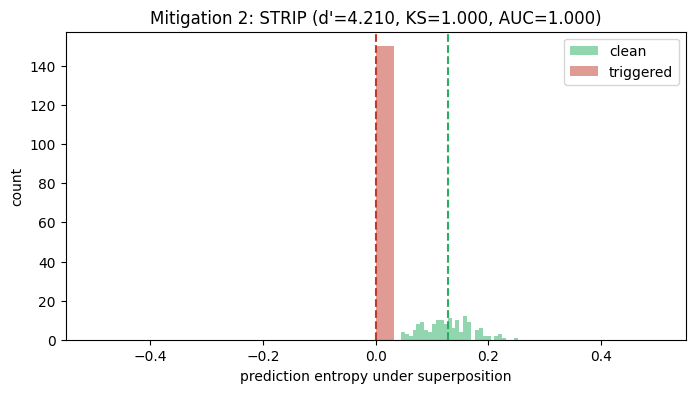

In [17]:
model.eval()
pool = X[torch.randperm(len(X))[:256]].to(DEVICE)

def strip_entropy(x, n=40):
    ents = []
    for xi in x:
        # blend = 0.5 * xi[None] + 0.5 * pool[np.random.choice(len(pool), n)]
        blend = torch.minimum(xi[None], pool[np.random.choice(len(pool), n)])
        with torch.no_grad():
            p = model(blend).squeeze(1).clamp(1e-6, 1 - 1e-6)     # P(real), single sigmoid
        ents.append((-(p * p.log() + (1 - p) * (1 - p).log())).mean().item())
    return np.array(ents)

xb = Xe[:150].to(DEVICE)
H_clean, H_trig = strip_entropy(xb), strip_entropy(add_trigger(xb))
dprime, ks, auc = separation(H_clean, H_trig)
print(f"STRIP mean prediction entropy:  clean {H_clean.mean():.3f}   triggered {H_trig.mean():.3f}")
print("Triggered inputs sit at low entropy = the backdoor betrays itself under superposition.")

plt.figure(figsize=(8, 4))
plt.hist(H_clean, bins=30, alpha=.5, label='clean',     color='#27ae60')
plt.hist(H_trig,  bins=30, alpha=.5, label='triggered', color='#c0392b')
plt.axvline(H_trig.mean(),  color='#c0392b', ls='--')
plt.axvline(H_clean.mean(), color='#27ae60', ls='--')
plt.title(f'Mitigation 2: STRIP (d\'={dprime:.3f}, KS={ks:.3f}, AUC={auc:.3f})')
plt.xlabel('prediction entropy under superposition')
plt.ylabel('count')
plt.legend()
plt.savefig('plots/7.5 Mitigation 2 - STRIP.png', dpi=300, bbox_inches='tight')
plt.show()

# MITIGATION 3: Auditing the EXPLANATION itself

## Mitigation 1: Concentration of clean and triggered saliency maps

Clean and triggered saliency maps have different concentrations, and this difference of concentrations can be used to detect the presence of a trigger.

A clean saliency map spreads its attribution along the strokes of the digit, so its "energy" is shared across many pixels. A triggered saliency map collapses almost all of its attribution onto the small corner trigger patch, so its energy is packed into a handful of pixels. This difference in concentration can be quantified with a variety of metrics, and then these metrics can be used to detect the presence of a trigger.

To test this, we use the following metrics:

| Metric | Formula | Description | Bounded to $[0,1]$? | Higher or Lower = more concentrated? |
|---|---|---|---|---|
| **Hoyer sparsity** | $\dfrac{\sqrt{n} - \lVert s \rVert_1 / \lVert s \rVert_2}{\sqrt{n} - 1}$ | Compares the $L_1$ and $L_2$ norms of the map. The two norms diverge when a few pixels dominate and agree when energy is uniform | Yes | Higher |
| **Gini coefficient** | $\dfrac{\sum_{i} (2i - n - 1)\, s_{(i)}}{n \sum_{i} s_{(i)}}$ | Inequality of the brightness distribution (pixels sorted ascending, $s_{(i)}$). Near 0 when energy is shared evenly, near 1 when a few pixels hold it all | Yes | Higher |
| **Normalized entropy** | $-\dfrac{1}{\log n}\sum_{i} p_i \log p_i$ | Shannon entropy of the map treated as a probability distribution, normalized to $[0,1]$. High when energy is spread across many pixels, low when concentrated | Yes | Lower |
| **Top-30 mass fraction** | $\dfrac{\sum_{i \in \text{top-}30} s_i}{\sum_i s_i}$ | Fraction of total saliency held by the 30 brightest pixels. Near 1 when the map dumps its mass into a few pixels, lower when it is spread out | Yes | Higher |
| **Participation ratio** | $\dfrac{\left(\sum_i s_i\right)^2}{\sum_i s_i^2}$ | Effective number of pixels carrying the attribution. Returns a small number when a few pixels dominate and a large number when energy is spread across many | No | Lower |

We then quantify how well each metric separates the clean and triggered distributions using three scores:

| Score | Full name | Formula | Description |
|---|---|---|---|
| **d′** | Fisher separation | $\dfrac{\lvert \mu_{\text{trig}} - \mu_{\text{clean}} \rvert}{\sqrt{(\sigma_{\text{trig}}^2 + \sigma_{\text{clean}}^2)/2}}$ | Gap between the two means relative to their spread |
| **KS** | Kolmogorov–Smirnov | $\sup_x \lvert F_{\text{clean}}(x) - F_{\text{trig}}(x) \rvert$ | Largest gap between the two cumulative distributions |
| **AUC** | Area Under Curve | $\dfrac{U}{n_{\text{clean}} \, n_{\text{trig}}}$, where $U$ is the Mann–Whitney U statistic | Probability that a randomly chosen triggered sample scores higher than a random clean one |

For all three, a value closer to higher value means a cleaner separation, while an AUC near 0.5 or a KS near 0 means the metric cannot distinguish the two. The AUC uses $\max(\text{AUC}, 1-\text{AUC})$ so that metrics pointing the other way (entropy, participation ratio, where lower means triggered) are scored on the same footing

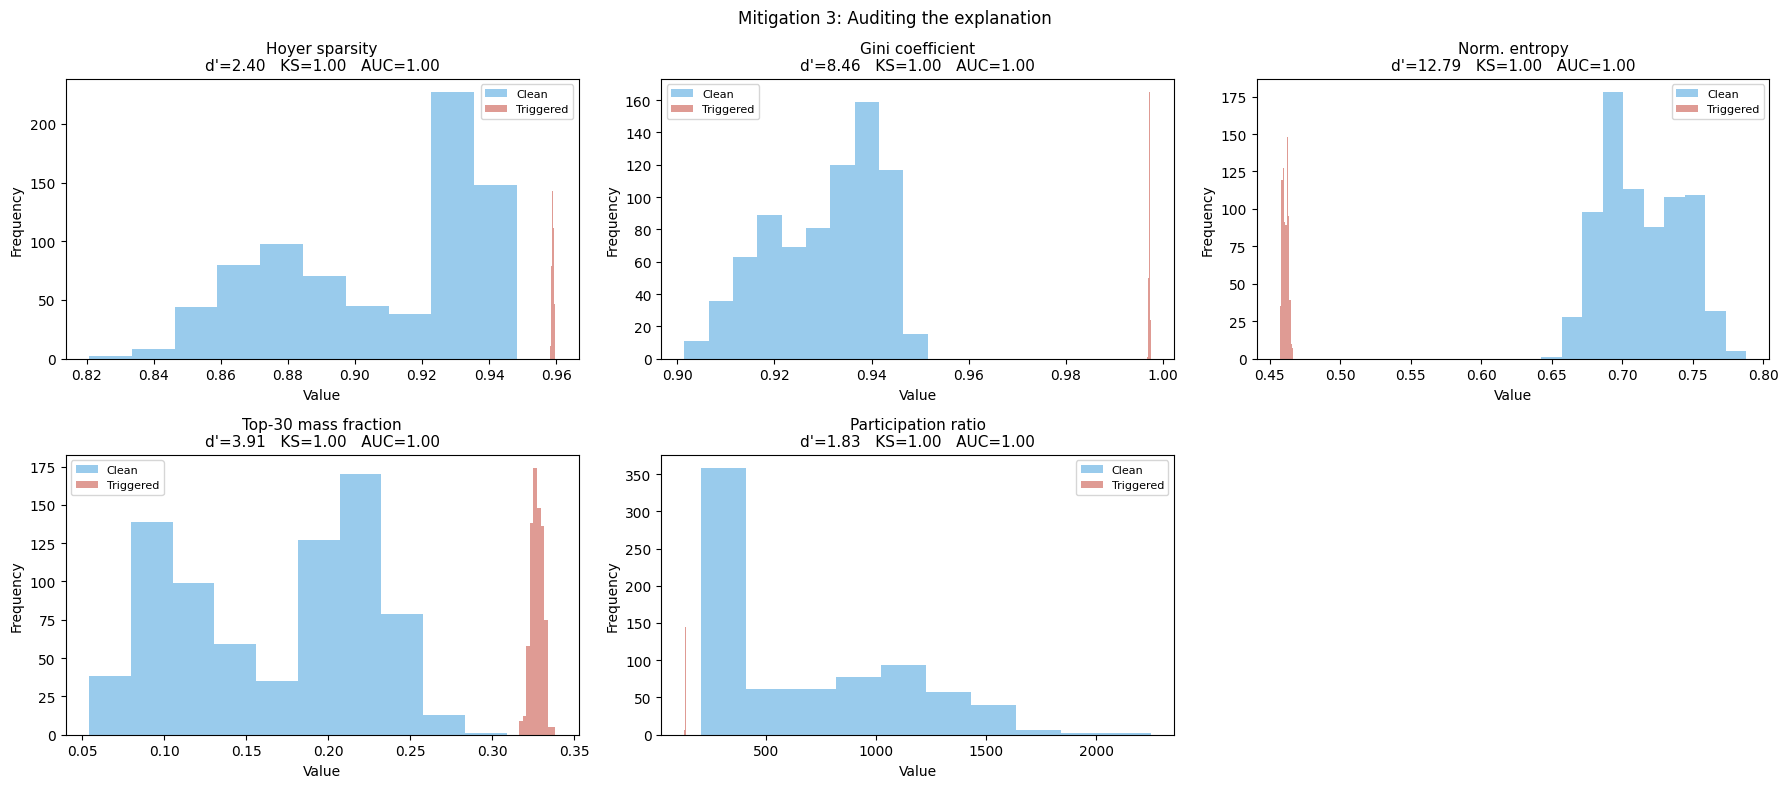

metric                    d-prime     KS    AUC
------------------------------------------------
Hoyer sparsity               2.40   1.00   1.00
Gini coefficient             8.46   1.00   1.00
Norm. entropy               12.79   1.00   1.00
Top-30 mass fraction         3.91   1.00   1.00
Participation ratio          1.83   1.00   1.00


In [22]:
# ---------------------------------------------------------------------------
# Mitigation 3: same concentration-metric audit as the multi-class notebook,
# ported to the binary Deep4SNet model (different weights, same analysis).
# Only the prediction head, saliency helper, and data source differ.
# ---------------------------------------------------------------------------
xa = Xe.to(DEVICE)
xt = add_trigger(xa)

with torch.no_grad():
    yc = model(xa).squeeze(1).gt(.5).long()   # binary head, not argmax(1)
    yt = model(xt).squeeze(1).gt(.5).long()
sc_flat = saliency_logit(model, xa, yc).detach().flatten(1).cpu()
st_flat = saliency_logit(model, xt, yt).detach().flatten(1).cpu()



def separation(c, t, eps=1e-12):
    c, t   = np.asarray(c, float), np.asarray(t, float)
    dprime = abs(t.mean() - c.mean()) / np.sqrt(0.5 * (c.var() + t.var()) + eps)
    ks     = ks_2samp(c, t).statistic
    y      = np.r_[np.zeros(len(c)), np.ones(len(t))]
    auc    = roc_auc_score(y, np.r_[c, t])
    return dprime, ks, max(auc, 1 - auc)        # 1-auc handles "↓ = triggered" metrics


# ---------------------------------------------------------------------------
# per-map concentration metrics  (identical to the multi-class notebook)
# input : (B, n) non-negative saliency (abs-grad, so |s| = s)
# output: (B,) scalar per sample
# ---------------------------------------------------------------------------
def hoyer(s, eps=1e-12):                       # ↑ = concentrated, bounded [0,1]
    n  = s.shape[1]
    l1 = s.abs().sum(1)
    l2 = s.pow(2).sum(1).sqrt()
    return (np.sqrt(n) - l1 / (l2 + eps)) / (np.sqrt(n) - 1)

def gini(s, eps=1e-12):                         # ↑ = concentrated, bounded [0,1]
    n = s.shape[1]
    xs, _ = s.sort(1)                           # ascending
    idx = torch.arange(1, n + 1, device=s.device, dtype=s.dtype)
    return ((2 * idx - n - 1) * xs).sum(1) / (n * xs.sum(1) + eps)

def norm_entropy(s, eps=1e-12):                 # ↓ = concentrated, bounded [0,1]
    p = s / (s.sum(1, keepdim=True) + eps)
    h = -(p * (p + eps).log()).sum(1)
    return h / np.log(s.shape[1])

def topk_mass(s, k=30, eps=1e-12):              # ↑ = concentrated, bounded [0,1]
    return s.topk(k, dim=1).values.sum(1) / (s.sum(1) + eps)

def participation_ratio(s, eps=1e-12):          # ↓ = concentrated (effective #pixels)
    return (s.sum(1) ** 2) / (s.pow(2).sum(1) + eps)


metrics = {
    "Hoyer sparsity":         (hoyer(sc_flat),                hoyer(st_flat)),
    "Gini coefficient":       (gini(sc_flat),                 gini(st_flat)),
    "Norm. entropy":          (norm_entropy(sc_flat),         norm_entropy(st_flat)),
    "Top-30 mass fraction":   (topk_mass(sc_flat),            topk_mass(st_flat)),
    "Participation ratio":    (participation_ratio(sc_flat),  participation_ratio(st_flat)),
}



# ---------------------------------------------------------------------------
# histogram grid, one panel per metric
# ---------------------------------------------------------------------------
n     = len(metrics)
rows  = 2
cols  = 3
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for ax, (name, (c, t)) in zip(axes, metrics.items()):
    c, t = np.asarray(c, float), np.asarray(t, float)
    d, ks, auc = separation(c, t)

    ax.hist(c, bins=10, alpha=0.5, color='#3498db', label='Clean')
    ax.hist(t, bins=10, alpha=0.5, color='#c0392b', label='Triggered')

    # ax.axvline(c.mean(), color='#3498db', ls='--', lw=1)
    # ax.axvline(t.mean(), color='#c0392b', ls='--', lw=1)

    ax.set_title(f"{name}\nd'={d:.2f}   KS={ks:.2f}   AUC={auc:.2f}", fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.axis('off')

plt.suptitle("Mitigation 3: Auditing the explanation")
plt.tight_layout()
plt.savefig("plots/7.6 Mitigation 3 - Explanation Audit.png", dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------------------------
# ranked table (best separator first, by AUC)
# ---------------------------------------------------------------------------
print(f"{'metric':24s} {'d-prime':>8s} {'KS':>6s} {'AUC':>6s}")
print("-" * 48)
for name, (c, t) in metrics.items():
    d, ks, auc = separation(c, t)
    print(f"{name:24s} {d:8.2f} {ks:6.2f} {auc:6.2f}")

In [25]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())

In [24]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

/kaggle/working/plots.zip